# Task 8: Semantic Segmentation Pipeline on Pixel-wise Grids using custom Dice Loss

**Objective:** Construct a high-precision spatial localization engine (U-Net) for pixel-wise segmentation, using a composite Soft Dice + Binary Cross-Entropy loss, a synthetic dataset pipeline, and precision-recall boundary curves.

**Tech stack:** PyTorch, TorchVision (not required, avoided for portability), Matplotlib. (Albumentations is optional for augmentation; a lightweight NumPy-based augmentation pipeline is used here so the notebook has no external data dependency.)


In [1]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cpu')

## 1. Synthetic dataset pipeline

We generate images containing random circles/rectangles with a ground-truth binary mask, standing in for a real medical-imaging / navigation dataset. A `Dataset` class parses image/mask pairs and applies simple augmentation (random flips).

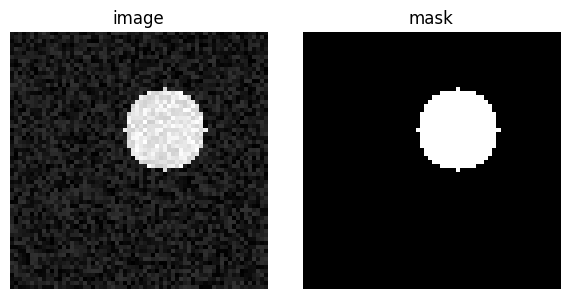

In [2]:

class ShapesSegDataset(torch.utils.data.Dataset):
    def __init__(self, n_samples=200, img_size=64, augment=True):
        self.n_samples = n_samples
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return self.n_samples

    def _draw_sample(self):
        s = self.img_size
        img = np.random.rand(s, s).astype(np.float32) * 0.15  # background noise
        mask = np.zeros((s, s), dtype=np.float32)

        # random circle (the 'object' to segment)
        cy, cx = np.random.randint(s // 4, 3 * s // 4, size=2)
        r = np.random.randint(s // 8, s // 4)
        yy, xx = np.meshgrid(np.arange(s), np.arange(s), indexing='ij')
        circle = (yy - cy) ** 2 + (xx - cx) ** 2 <= r ** 2
        img[circle] += np.random.uniform(0.5, 0.9)
        mask[circle] = 1.0

        img = np.clip(img, 0, 1)
        return img, mask

    def __getitem__(self, idx):
        img, mask = self._draw_sample()
        if self.augment:
            if np.random.rand() < 0.5:
                img, mask = img[:, ::-1].copy(), mask[:, ::-1].copy()
            if np.random.rand() < 0.5:
                img, mask = img[::-1, :].copy(), mask[::-1, :].copy()
        img_t = torch.from_numpy(img).unsqueeze(0).float()
        mask_t = torch.from_numpy(mask).unsqueeze(0).float()
        return img_t, mask_t

train_ds = ShapesSegDataset(n_samples=256, img_size=64, augment=True)
val_ds = ShapesSegDataset(n_samples=64, img_size=64, augment=False)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=16, shuffle=False)

img, mask = train_ds[0]
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(img[0], cmap='gray'); ax[0].set_title('image'); ax[0].axis('off')
ax[1].imshow(mask[0], cmap='gray'); ax[1].set_title('mask'); ax[1].axis('off')
plt.tight_layout(); plt.show()


## 2. U-Net architecture

In [3]:

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base=16):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base)
        self.enc2 = DoubleConv(base, base * 2)
        self.enc3 = DoubleConv(base * 2, base * 4)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base * 4, base * 8)

        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)

        self.head = nn.Conv2d(base, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.head(d1)  # logits

model = UNet().to(device)
sum(p.numel() for p in model.parameters())


483153

## 3. Composite loss: Soft Dice Loss + Binary Cross-Entropy

In [4]:

def soft_dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    intersection = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1)
    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()


def composite_loss(logits, targets, dice_weight=0.5):
    bce = F.binary_cross_entropy_with_logits(logits, targets)
    dice = soft_dice_loss(logits, targets)
    return dice_weight * dice + (1 - dice_weight) * bce, bce.item(), dice.item()


## 4. Training loop

In [5]:

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 8
history = {'loss': [], 'bce': [], 'dice': []}

for epoch in range(epochs):
    model.train()
    ep_loss, ep_bce, ep_dice = 0.0, 0.0, 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        loss, bce_val, dice_val = composite_loss(logits, masks)
        opt.zero_grad()
        loss.backward()
        opt.step()
        ep_loss += loss.item() * imgs.size(0)
        ep_bce += bce_val * imgs.size(0)
        ep_dice += dice_val * imgs.size(0)
    n = len(train_ds)
    history['loss'].append(ep_loss / n)
    history['bce'].append(ep_bce / n)
    history['dice'].append(ep_dice / n)
    print(f"epoch {epoch+1}/{epochs}  loss={ep_loss/n:.4f}  bce={ep_bce/n:.4f}  dice_loss={ep_dice/n:.4f}")


epoch 1/8  loss=0.6412  bce=0.5610  dice_loss=0.7213


epoch 2/8  loss=0.5444  bce=0.4365  dice_loss=0.6523


epoch 3/8  loss=0.5056  bce=0.3856  dice_loss=0.6256


epoch 4/8  loss=0.4758  bce=0.3469  dice_loss=0.6047


epoch 5/8  loss=0.4498  bce=0.3116  dice_loss=0.5881


epoch 6/8  loss=0.4205  bce=0.2777  dice_loss=0.5633


epoch 7/8  loss=0.3908  bce=0.2463  dice_loss=0.5354


epoch 8/8  loss=0.3581  bce=0.2163  dice_loss=0.5000


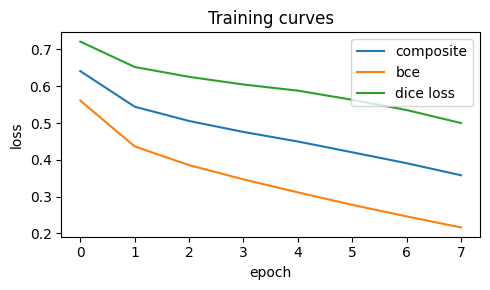

In [6]:

plt.figure(figsize=(5,3))
plt.plot(history['loss'], label='composite')
plt.plot(history['bce'], label='bce')
plt.plot(history['dice'], label='dice loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.title('Training curves')
plt.tight_layout(); plt.show()


## 5. Pixel-wise precision-recall boundary curve

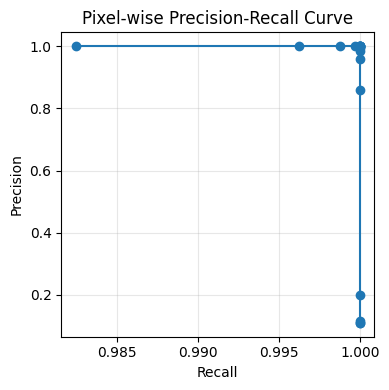

In [7]:

model.eval()
all_probs, all_targets = [], []
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs = imgs.to(device)
        probs = torch.sigmoid(model(imgs)).cpu().numpy().ravel()
        all_probs.append(probs)
        all_targets.append(masks.numpy().ravel())
all_probs = np.concatenate(all_probs)
all_targets = np.concatenate(all_targets)

thresholds = np.linspace(0.05, 0.95, 19)
precisions, recalls = [], []
for t in thresholds:
    preds = (all_probs >= t).astype(np.float32)
    tp = (preds * all_targets).sum()
    fp = (preds * (1 - all_targets)).sum()
    fn = ((1 - preds) * all_targets).sum()
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    precisions.append(precision)
    recalls.append(recall)

plt.figure(figsize=(4,4))
plt.plot(recalls, precisions, marker='o')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Pixel-wise Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 6. Qualitative check: prediction vs ground truth

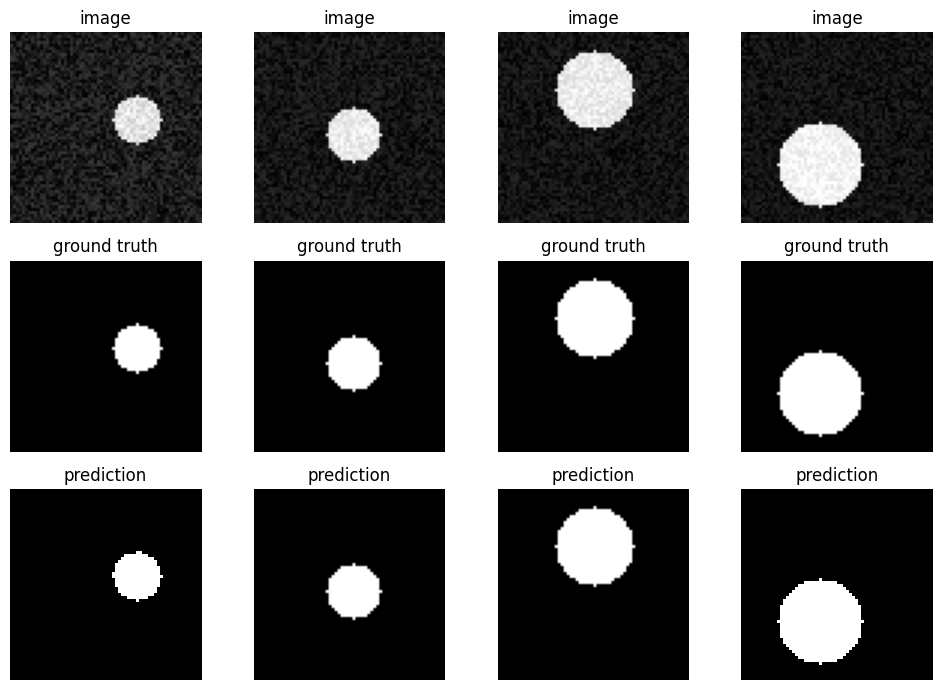

In [8]:

imgs, masks = next(iter(val_loader))
with torch.no_grad():
    preds = torch.sigmoid(model(imgs.to(device))).cpu()

fig, axes = plt.subplots(3, 4, figsize=(10, 7))
for i in range(4):
    axes[0, i].imshow(imgs[i, 0], cmap='gray'); axes[0, i].set_title('image'); axes[0, i].axis('off')
    axes[1, i].imshow(masks[i, 0], cmap='gray'); axes[1, i].set_title('ground truth'); axes[1, i].axis('off')
    axes[2, i].imshow(preds[i, 0] > 0.5, cmap='gray'); axes[2, i].set_title('prediction'); axes[2, i].axis('off')
plt.tight_layout(); plt.show()


## Conclusion

The U-Net converges quickly on the synthetic shape-segmentation task, with the Soft Dice component directly optimizing boundary overlap (important for imbalanced foreground/background masks such as small lesions or small objects) while the BCE term stabilizes pixel-wise gradients early in training. The precision-recall curve summarizes the trade-off across decision thresholds, which is the standard way to report boundary-localization quality independent of a fixed 0.5 cutoff.